In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

In [2]:
markers = ['o', '*', 'v', '^', '<', 's']
sns.set_palette(palette=['#003f5c','#ff6e54','#444e86','#955196','#dd5182', '#ffa600'])
plt.rcParams.update({"text.usetex": True, "font.family" : "serif", "font.serif" : ["Computer Modern Serif"]})

In [3]:
d = pd.read_csv("../results_jooken/results.csv")

# Relevant data

In [4]:
### Number of feasible instances.
ni = len(d.instance.unique())
ni

1685

In [5]:
### Number of instances solved optimally by the compact formulation.

c_opt = len(d[(d.algorithm == 'compact') & d.optimal])
c_opt, c_opt / ni

(1374, 0.8154302670623146)

In [6]:
### Number of instances solved optimally by the extended formulation.

e_opt = len(d[(d.algorithm == 'mckp') & d.optimal])
e_opt, e_opt / ni

(1685, 1.0)

In [7]:
### Number of instances solved optimally by the compact formulation within one second.

c_fast = len(d[(d.algorithm == 'compact') & d.optimal & (d.time_elapsed <= 1)])
c_fast, c_fast / ni

(1079, 0.6403560830860534)

In [8]:
### Number of instances solved optimally by the extended formulation within one second.

e_fast = len(d[(d.algorithm == 'mckp') & d.optimal & (d.time_elapsed <= 1)])
e_fast, e_fast / ni

(0, 0.0)

# Performance Profile

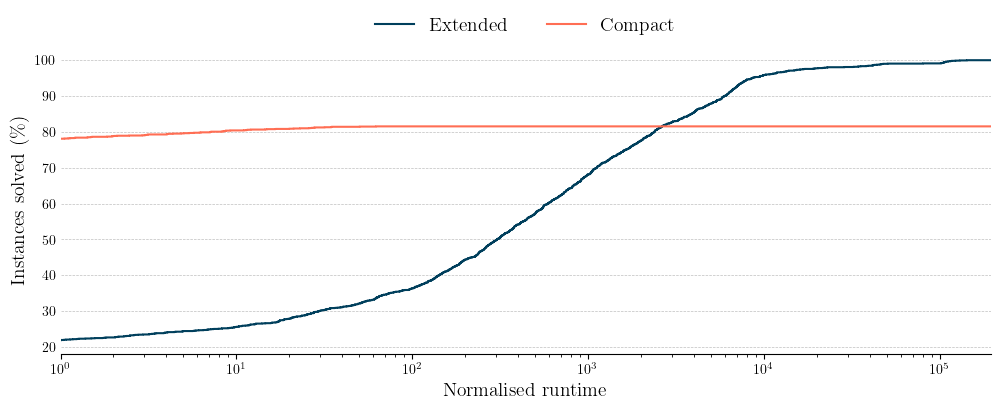

In [9]:
fig, ax = plt.subplots(figsize=(12,4))

d['fastest'] = d.groupby('instance')['time_elapsed'].transform('min')
d['runtime_ratio'] = d.time_elapsed / d.fastest
d.drop(columns='fastest', inplace=True)

for idx, algorithm in enumerate(d.algorithm.unique()):
    da = d[d.algorithm == algorithm]
    ptsx, ptsy = list(), list()

    for r in sorted(d.runtime_ratio.unique()):
        ptsx.append(r)
        ptsy.append(100 * len(da[(da.runtime_ratio <= r) & da.optimal]) / ni)

    algo_name = 'Compact' if algorithm == 'compact' else 'Extended'
    ax.step(ptsx, ptsy, color=f"C{idx}", label=algo_name)

ax.set_xlabel('Normalised runtime', fontsize=14)
ax.set_ylabel('Instances solved (\\%)', fontsize=14)
ax.set_xscale('log')
ax.set_xlim(1, d.runtime_ratio.max())

ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.tick_params(axis='y', size=0)
ax.grid(which='major', axis='y', ls='--', lw=0.5, color='black', alpha=0.25)

ax.legend(ncols=2, loc='upper center', frameon=False, bbox_to_anchor=(0.5, 1.15), fontsize=14);

In [10]:
fig.savefig('performance_profile_jookens.pdf', dpi=300, bbox_inches='tight');

# Compact formulation bar chart

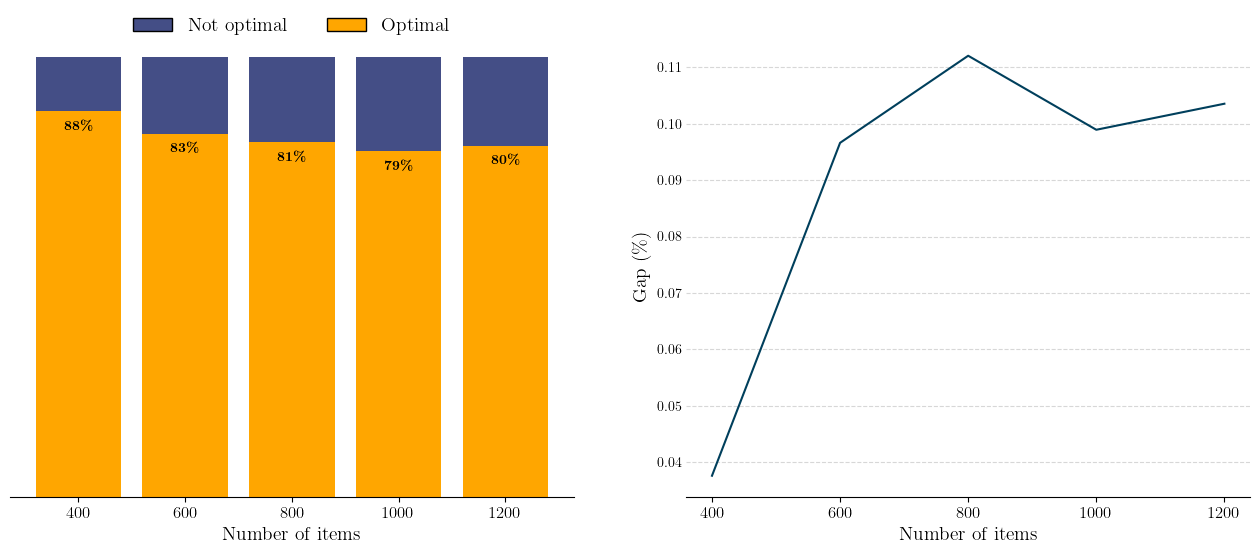

In [11]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(16, 6))
dc = d[d.algorithm == 'compact'].copy()

ax = axes.flat[0]
nit = sorted(dc.num_items.unique())
solved = list()
unsolved = list()

for ni in nit:
    dk = dc[dc.num_items == ni]
    solved.append(100 * len(dk[dk.optimal]) / len(dk))
    unsolved.append(100 - solved[-1])

ax.bar(x=range(len(nit)), height=solved, color='C5')
ax.bar(x=range(len(nit)), height=unsolved, bottom=solved, color='C2')
ax.set_xticks(range(len(nit)))
ax.set_xticklabels(map(str, nit), ha='center', fontsize=12)
ax.set_xlabel('Number of items', fontsize=14)

ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_yticks(list())

for idx, val in enumerate(solved):
    ax.text(x=idx, y=val-2, s=f"\\textbf{{{val:.0f}\\%}}", ha='center', va='top')

h = [Rectangle(xy=[0,0], height=5, width=10, facecolor=c, edgecolor='k') for c in ('C2', 'C5')]
ax.legend(h, ["Not optimal", "Optimal"], ncols=2, title=None, fontsize=14, loc='upper center', bbox_to_anchor=(0.5, 1.075), frameon=False)

ax = axes.flat[1]
dp = dc[['num_items', 'gap_pct']].groupby('num_items').mean().reset_index().sort_values('num_items')

ax.plot(range(len(dp.num_items)), dp.gap_pct)
ax.set_xticks(range(len(dp.num_items)))
ax.set_xticklabels(map(str, dp.num_items), ha='center', fontsize=12)
ax.set_xlabel('Number of items', fontsize=14)
ax.set_ylabel('Gap (\\%)', fontsize=14)

ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.tick_params(axis='y', length=0)
ax.grid(which='major', axis='y', ls='--', alpha=0.5);

In [12]:
fig.savefig('compact_res_jookens.pdf', dpi=300, bbox_inches='tight');

# Extended formulation times

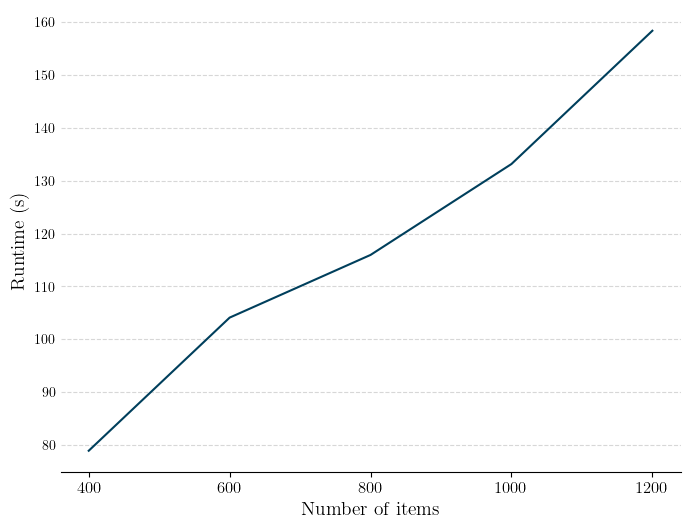

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
dc = d[d.algorithm == 'mckp'].copy()
dp = dc[['num_items', 'time_elapsed']].groupby('num_items').mean().reset_index().sort_values('num_items')

ax.plot(range(len(dp.num_items)), dp.time_elapsed)
ax.set_xticks(range(len(dp.num_items)))
ax.set_xticklabels(map(str, dp.num_items), ha='center', fontsize=12)
ax.set_xlabel('Number of items', fontsize=14)
ax.set_ylabel('Runtime (s)', fontsize=14)

ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.tick_params(axis='y', length=0)
ax.grid(which='major', axis='y', ls='--', alpha=0.5)

In [14]:
fig.savefig('extended_res_jookens.pdf', dpi=300, bbox_inches='tight');